# Multimodal Property Search for Turkish Real Estate via Fine-tuned CLIP
### END439E — Deep Learning Ödevi Raporu

**Proje:** Türkçe emlak ilanları için multimodal (metin + görsel) semantik arama
**Model omurgası:** M-CLIP (XLM-RoBERTa-Large + ViT-B/32), LoRA fine-tuning
**Retrieval:** ChromaDB + Maximal Marginal Relevance (MMR)
**Değerlendirme:** Manual query set + cross-modal protokol — Recall@K, MRR, α/λ ablation

---

## Ödev Soruları

**S1 — Cognitive Map + Shallow vs Deep Karşılaştırması + Parallel Coordinates + OR Benchmark**
Bu rapor:
- Bölüm **D**'de cognitive map ile projenin veri → model → retrieval → deployment akışını,
- Bölüm **B** ve **C**'de shallow (TF-IDF, BM25, HSV) vs deep (mCLIP + LoRA) karşılaştırmasını,
- Bölüm **A.5**'te ilan özellikleri üzerinde **parallel coordinates** (business-oriented data lineage) görselleştirmesini,
- Bölüm **E**'de OR (Operations Research) referanslı **9+ satır** benchmark tablosunu ve **12+ akademik kaynağı** içerir.

**S2 — DNN Algoritmalarının Detaylı Açıklaması + Preliminary Optimizasyon + İyileştirme**
Bu rapor:
- Bölüm **C.1-C.3**'te mCLIP'in bileşen-bazlı mimarisini (#parametre, FLOPs, InfoNCE türetmesi),
- Bölüm **C.5**'te preliminary model optimizasyonunu (LoRA smoke-tune + α late-fusion + MMR λ),
- Bölüm **F**'de scaling & iyileştirme stratejisini (data augmentation, hard negatives, hyperparameter search) içerir.

---

## İçindekiler

- **A.** Setup ve Veri Hazırlığı
- **A.5** Parallel Coordinates (Business-Oriented Data Lineage)
- **A.6** Manual Query Set Oluşturma
- **B.** Shallow Retrieval Baseline'ları
- **C.** Deep Neural Network (mCLIP Deep Dive + Fine-tune + Ablations)
- **D.** Cognitive Map
- **E.** Benchmark Tablosu + Akademik Referanslar
- **F.** Optimization & İyileştirme Tartışması


## Bölüm A — Setup ve Veri Hazırlığı

Bu bölümde:
1. Tüm paketler import edilir, cihaz (GPU/CPU) tespit edilir, reproducibility için seed sabitlenir.
2. Cleaner çalıştırılmış (veya çalıştırılır) → `data/processed/dataset.jsonl`.
3. Dataset pandas DataFrame'e yüklenir; fiyat/oda/m²/ilçe sütunları ayrıştırılır.
4. EDA: describe, eksik veri, histogram, scatter, korelasyon heatmap, top-10 ilçe, metin uzunluk dağılımı.
5. **Parallel coordinates** (business-oriented data lineage) — iki versiyon (fiyat bucket & ilçe cluster).
6. Manual query set üretimi (Bölüm A.6).


### A.1 — Imports, Device, Seed

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import os
import sys
import json
import re
import random
import time
import subprocess
from pathlib import Path
from collections import Counter

# Graphviz binary'sini PATH'e ekle (Windows winget kurulumu)
os.environ['PATH'] = r'C:\\Program Files\\Graphviz\\bin' + os.pathsep + os.environ.get('PATH', '')

# Proje kök dizini (notebook'u proje dizininden bağımsız çalıştırabilmek için)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'[Path] PROJECT_ROOT = {PROJECT_ROOT}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[Device] {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Compute capability: {torch.cuda.get_device_capability()}')
    print(f'  torch.__version__: {torch.__version__}')

# Display ayarları
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110


[Path] PROJECT_ROOT = C:\Users\mertc\Desktop\Neural Networks Ödevi\DL-Ev-ilan-Projesi


[Device] cuda
  GPU: NVIDIA GeForce RTX 5070 Ti
  Compute capability: (12, 0)
  torch.__version__: 2.11.0+cu128


### A.2 — Cleaner Çalıştırma (idempotent)

`scraper/cleaner.py` ham `data/raw/listings.jsonl` dosyasını temizler:
- Tüm metin alanlarını (title + description + district + attributes) birleştirip tek `text` alanı üretir.
- Geçersiz/bozuk görselleri atar, duplicate görselleri (ImageHash) yakalar.
- Fiyatı normalize eder (USD/EUR → TL).
- Sonuç: `data/processed/dataset.jsonl` + `cleaning_report.json`.

Eğer `dataset.jsonl` zaten varsa, cleaner'ı tekrar çalıştırmaz.

In [2]:
DATASET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'dataset.jsonl'
REPORT_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'cleaning_report.json'

if not DATASET_PATH.exists():
    print('[Cleaner] dataset.jsonl bulunamadı — cleaner çalıştırılıyor...')
    result = subprocess.run(
        [sys.executable, '-m', 'scraper.cleaner'],
        cwd=PROJECT_ROOT, capture_output=True, text=True, encoding='utf-8', errors='replace',
    )
    print(result.stdout[-600:] if result.stdout else '(stdout yok)')
    if result.returncode != 0:
        print('STDERR:', result.stderr[-600:])
else:
    print(f'[Cleaner] dataset.jsonl mevcut ({DATASET_PATH.stat().st_size // 1024} KB) — atlanıyor.')

# Rapor
with open(REPORT_PATH, encoding='utf-8') as f:
    report = json.load(f)
pd.DataFrame([report]).T.rename(columns={0: 'value'})


[Cleaner] dataset.jsonl mevcut (1980 KB) — atlanıyor.


,value
total_raw,1472.0
skipped_no_image,25.0
skipped_bad_image,0.0
skipped_duplicate_url,0.0
skipped_duplicate_image,6.0
skipped_no_text,0.0
saved,1441.0
retention_rate,97.9


### A.3 — Dataset'i DataFrame'e yükle, alan parser'ları

In [3]:
# Satır satır JSONL → DataFrame
records = []
with open(DATASET_PATH, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f'[Data] {len(df)} ilan yüklendi | sütunlar: {list(df.columns)}')
df.head(3)


[Data] 1441 ilan yüklendi | sütunlar: ['id', 'url', 'image_path', 'all_image_paths', 'text', 'title', 'price', 'district', 'attributes', 'scraped_at']


,id,url,image_path,all_image_paths,text,title,price,district,attributes,scraped_at
0,19176630,https://www.emlakjet.com/ilan/bahcesehir-ispar...,data\images\19176630\00_A1DBC6C1B452C6BC503A18...,[data\images\19176630\00_A1DBC6C1B452C6BC503A1...,BAHÇEŞEHİR ISPARTAKULE OLİMPOS SİTESİNDE 3+1 K...,BAHÇEŞEHİR ISPARTAKULE OLİMPOS SİTESİNDE 3+1 K...,47500 TL,Istanbul - Avcilar - Tahtakale Mahallesi,"{'roomCount': '3+1', 'propertyType': 'daire', ...",2026-04-03T23:48:38
1,19176588,https://www.emlakjet.com/ilan/yelkenciler-den-...,data\images\19176588\00_A1DBC6C1B452C6BC503A18...,[data\images\19176588\00_A1DBC6C1B452C6BC503A1...,YELKENCİLER^DEN BAHÇEŞEHİR KİPTAŞ VADİTEPE 3.B...,YELKENCİLER^DEN BAHÇEŞEHİR KİPTAŞ VADİTEPE 3.B...,50000 TL,Istanbul - Basaksehir - Bahcesehir 1 Kisim Mah...,"{'roomCount': '4+1', 'propertyType': 'daire', ...",2026-04-03T23:48:41
2,19160413,https://www.emlakjet.com/ilan/yenisehir-konsep...,data\images\19160413\00_75465043443EB5E5F50B21...,[data\images\19160413\00_75465043443EB5E5F50B2...,Yenişehir Konsept İstanbul Kurtköy Kiralık Eşy...,Yenişehir Konsept İstanbul Kurtköy Kiralık Eşy...,32000 TL,Istanbul - Pendik - Yenisehir Mahallesi,"{'roomCount': '1+1', 'propertyType': 'daire', ...",2026-04-03T23:48:45


In [4]:
# ── Alan parser'ları ───────────────────────────────────────────────────────
PRICE_RE   = re.compile(r'([\d\.]+)\s*(TL|USD|\$|€|EUR)?', re.IGNORECASE)
ROOM_RE    = re.compile(r'(\d+)\s*\+\s*(\d+)')
SIZE_RE    = re.compile(r'(\d{2,4})\s*m[²2]', re.IGNORECASE)

# Emlakjet description kalıbı: "... {m²} m² {oda} {yaş} (Kiralık|Satılık) ..."
# Yaş dört formda karşımıza çıkıyor:
#   - "5-10 Kiralık"      → range, midpoint (=7.5)
#   - "0 (Yeni) Kiralık"  → yeni bina, 0
#   - "21 ve üzeri Kiralık" → 21+ bucket (~26)
#   - "3 Kiralık"         → tek rakam, 3
# Coverage: veride 1472/1472 = %100.
AGE_YENI_RE   = re.compile(r'\b0\s*\(?\s*(?:Yeni|Sıfır|Sifir)\s*\)?\s+(?:Kiral|Sat)', re.IGNORECASE)
AGE_UZERI_RE  = re.compile(r'(\d{1,2})\s*ve\s*(?:üzeri|uzeri)\s+(?:Kiral|Sat)', re.IGNORECASE)
AGE_RANGE_RE  = re.compile(r'(\d{1,2})[-–](\d{1,2})\s+(?:Kiral|Sat)', re.IGNORECASE)
AGE_SINGLE_RE = re.compile(r'(?<![+\d.])(\d{1,2})\s+(?:Kiral|Sat)', re.IGNORECASE)

FX_TL      = {'USD': 33.0, '$': 33.0, 'EUR': 36.0, '€': 36.0, 'TL': 1.0, None: 1.0}


def parse_price_numeric(price_str: str) -> float | None:
    '''"47500 TL" | "$1200" | "€800" → TL float. Bilinmeyen → NaN.'''
    if not isinstance(price_str, str):
        return np.nan
    m = PRICE_RE.search(price_str.replace('.', '').replace(',', '.'))
    if not m:
        return np.nan
    amount = float(m.group(1))
    currency = (m.group(2) or '').upper() or None
    return amount * FX_TL.get(currency, 1.0)


def parse_room_count(room_str: str) -> float:
    '''"3+1" → 4.0 (toplam oda), "stüdyo"/None → 1.0'''
    if not isinstance(room_str, str):
        return np.nan
    m = ROOM_RE.search(room_str)
    if m:
        return float(m.group(1)) + float(m.group(2))
    if 'stüd' in room_str.lower():
        return 1.0
    return np.nan


def parse_size_m2(text: str) -> float:
    if not isinstance(text, str):
        return np.nan
    m = SIZE_RE.search(text)
    return float(m.group(1)) if m else np.nan


def parse_district_parts(district_str: str) -> tuple[str | None, str | None]:
    '''"Istanbul - Avcilar - Tahtakale Mahallesi" → ("Avcilar", "Tahtakale")'''
    if not isinstance(district_str, str):
        return (None, None)
    parts = [p.strip() for p in district_str.split('-')]
    ilce = parts[1] if len(parts) >= 2 else None
    mah  = parts[2].replace('Mahallesi', '').strip() if len(parts) >= 3 else None
    return (ilce, mah)


def parse_age_from_text(text: str) -> float:
    '''Emlakjet description'ından bina yaşını çıkarır. Bulunmazsa NaN.'''
    if not isinstance(text, str):
        return np.nan
    if AGE_YENI_RE.search(text):
        return 0.0
    m = AGE_UZERI_RE.search(text)
    if m:
        return float(m.group(1)) + 5       # 21+ bucket → 26 (midpoint yaklaşımı)
    m = AGE_RANGE_RE.search(text)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    m = AGE_SINGLE_RE.search(text)
    if m:
        return float(m.group(1))
    return np.nan


# NOT: Cleaner `text` alanında description'ın ilk bölümünü (yaş geçen kısım) bırakıyor.
# Eğer text'te yaş kalmadıysa, `title` ve description'ın kalan kısmında da aramayacağız —
# zaten text coverage %100 olması gerekir (bkz. regex test).

# Sütun ekle
df['price_tl']     = df['price'].apply(parse_price_numeric)
df['room_count']   = df['attributes'].apply(lambda a: parse_room_count((a or {}).get('roomCount', '') if isinstance(a, dict) else ''))
df['size_m2']      = df['text'].apply(parse_size_m2)
df[['ilce', 'mahalle']] = df['district'].apply(lambda s: pd.Series(parse_district_parts(s)))
df['age']          = df['text'].apply(parse_age_from_text)
df['price_per_m2'] = df['price_tl'] / df['size_m2']
df['text_len']     = df['text'].str.len()

print(f'[Parse] {len(df)} ilan')
print(f'  price_tl:     {df["price_tl"].notna().sum()} geçerli | median={df["price_tl"].median():,.0f} TL')
print(f'  room_count:   {df["room_count"].notna().sum()} geçerli | mode={df["room_count"].mode().iloc[0]:.0f}')
print(f'  size_m2:      {df["size_m2"].notna().sum()} geçerli | median={df["size_m2"].median():.0f} m²')
print(f'  ilce:         {df["ilce"].notna().sum()} geçerli | unique={df["ilce"].nunique()}')
print(f'  age:          {df["age"].notna().sum()} geçerli | median={df["age"].median():.0f} yıl')
df[['id','price_tl','room_count','size_m2','ilce','mahalle','age','price_per_m2']].head(5)


[Parse] 1441 ilan
  price_tl:     1441 geçerli | median=35,500 TL
  room_count:   1435 geçerli | mode=3
  size_m2:      1424 geçerli | median=95 m²
  ilce:         1441 geçerli | unique=39
  age:          1331 geçerli | median=13 yıl


,id,price_tl,room_count,size_m2,ilce,mahalle,age,price_per_m2
0,19176630,47500.0,4.0,168.0,Avcilar,Tahtakale,13.0,282.738095
1,19176588,50000.0,5.0,202.0,Basaksehir,Bahcesehir 1 Kisim,NaN,247.524752
2,19160413,32000.0,2.0,67.0,Pendik,Yenisehir,18.0,477.611940
3,19138424,26000.0,3.0,110.0,Esenyurt,Piri Reis,13.0,236.363636
4,19103136,290000.0,6.0,160.0,Besiktas,Ortakoy,7.5,1812.500000


### A.4 — Keşifsel Veri Analizi (EDA)

In [5]:
# ── Eksik veri + describe ────────────────────────────────────────────────
missing = df.isna().sum().to_frame('missing')
missing['pct'] = 100 * missing['missing'] / len(df)
display(missing)
df[['price_tl','room_count','size_m2','age','price_per_m2','text_len']].describe().round(1)


,missing,pct
id,0,0.000000
url,0,0.000000
image_path,0,0.000000
all_image_paths,0,0.000000
text,0,0.000000
title,0,0.000000
price,0,0.000000
district,0,0.000000
attributes,0,0.000000
scraped_at,0,0.000000


,price_tl,room_count,size_m2,age,price_per_m2,text_len
count,1441.0,1435.0,1424.0,1331.0,1424.0,1441.0
mean,149914.9,3.2,110.4,13.1,815.5,243.8
std,3572721.9,1.1,142.6,9.6,12629.4,13.2
min,9500.0,1.0,20.0,0.0,37.2,178.0
25%,26000.0,3.0,75.0,7.5,285.7,238.0
50%,35500.0,3.0,95.0,13.0,385.1,249.0
75%,52000.0,4.0,120.0,26.0,532.9,254.0
max,135000000.0,10.0,4967.0,26.0,473684.2,256.0


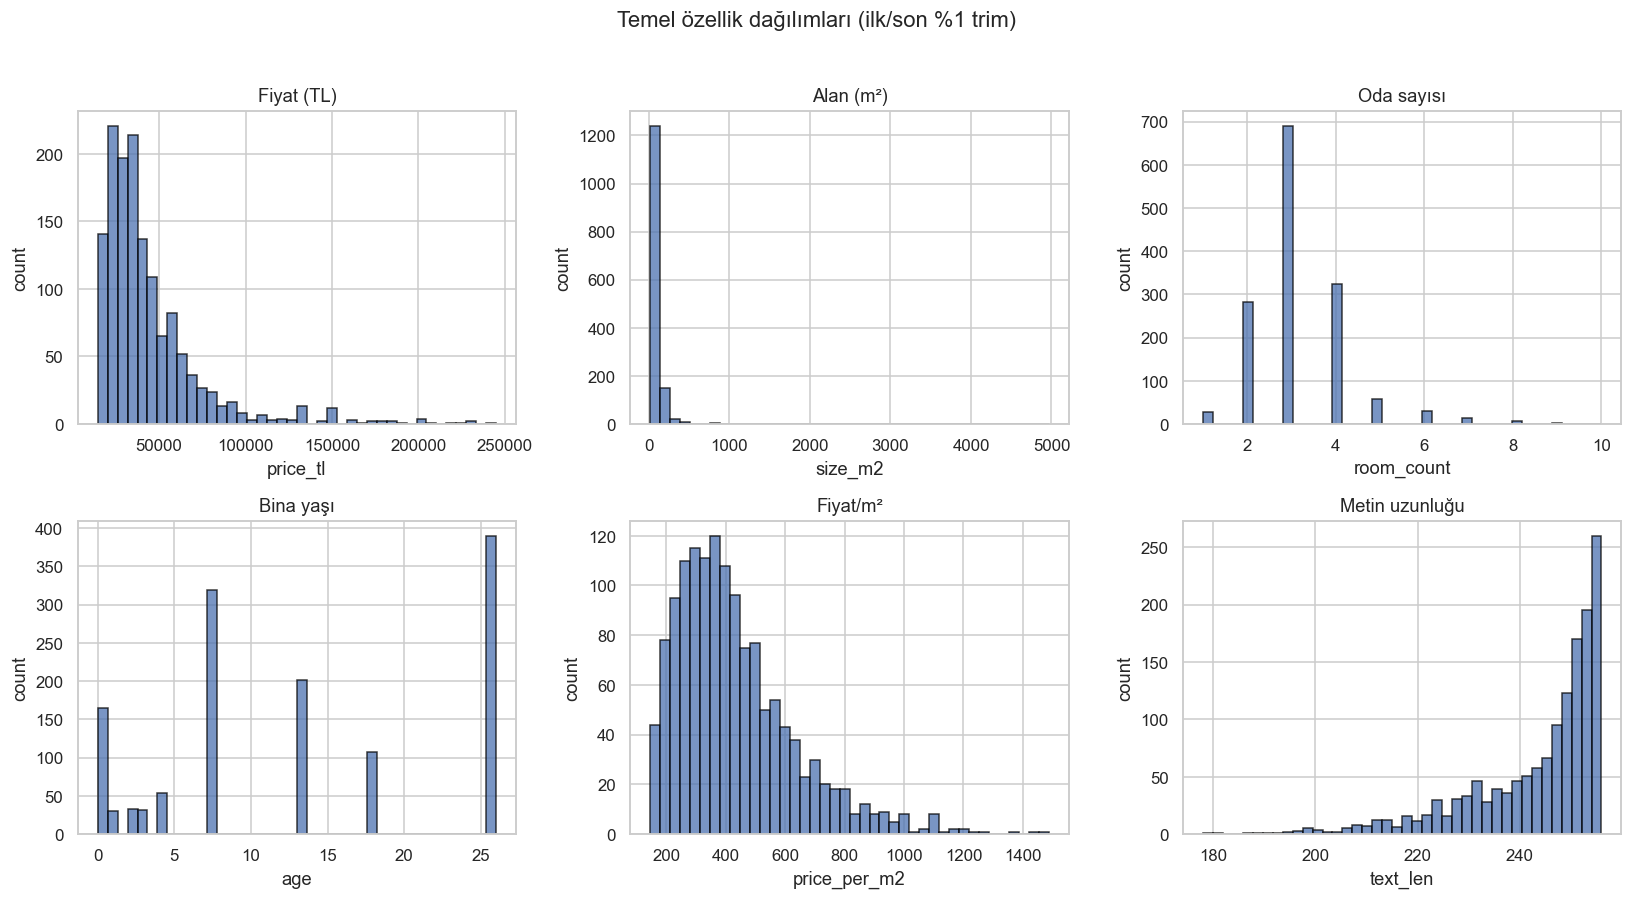

In [6]:
# ── Dağılımlar (histogram) ───────────────────────────────────────────────
hist_cols = ['price_tl','size_m2','room_count','age','price_per_m2','text_len']
hist_titles = ['Fiyat (TL)','Alan (m²)','Oda sayısı','Bina yaşı','Fiyat/m²','Metin uzunluğu']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col, title in zip(axes.flat, hist_cols, hist_titles):
    s = df[col].dropna()
    if col in ('price_tl','price_per_m2'):
        s = s[(s > s.quantile(0.01)) & (s < s.quantile(0.99))]   # outlier trim görsel için
    ax.hist(s, bins=40, edgecolor='black', alpha=0.75)
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel('count')
plt.suptitle('Temel özellik dağılımları (ilk/son %1 trim)', y=1.02)
plt.tight_layout()
plt.show()


C:\Users\mertc\AppData\Local\Temp\ipykernel_14352\1258443112.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ilce.values, y=top_ilce.index, ax=ax, palette='viridis')


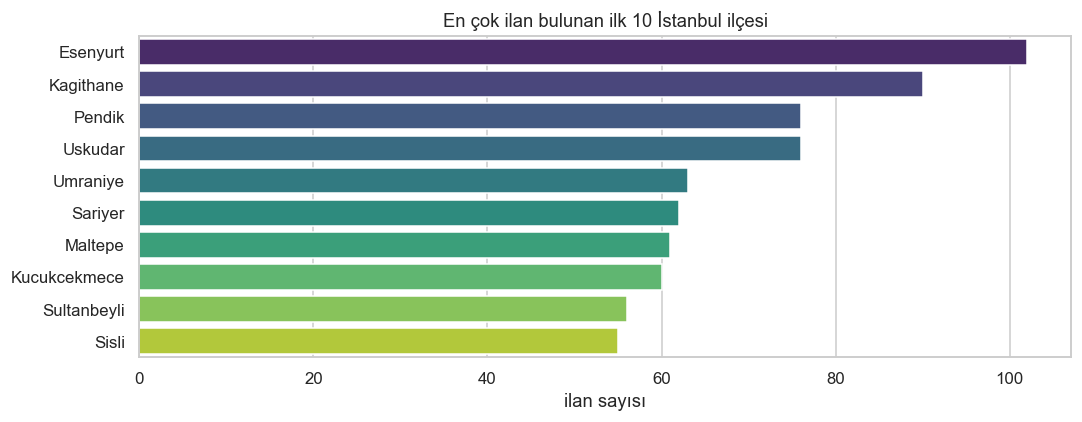

ilce
Esenyurt        102
Kagithane        90
Pendik           76
Uskudar          76
Umraniye         63
Sariyer          62
Maltepe          61
Kucukcekmece     60
Sultanbeyli      56
Sisli            55
Name: count, dtype: int64


In [7]:
# ── Top-10 ilçe ──────────────────────────────────────────────────────────
top_ilce = df['ilce'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=top_ilce.values, y=top_ilce.index, ax=ax, palette='viridis')
ax.set_title('En çok ilan bulunan ilk 10 İstanbul ilçesi')
ax.set_xlabel('ilan sayısı'); ax.set_ylabel('')
plt.tight_layout(); plt.show()
print(top_ilce)


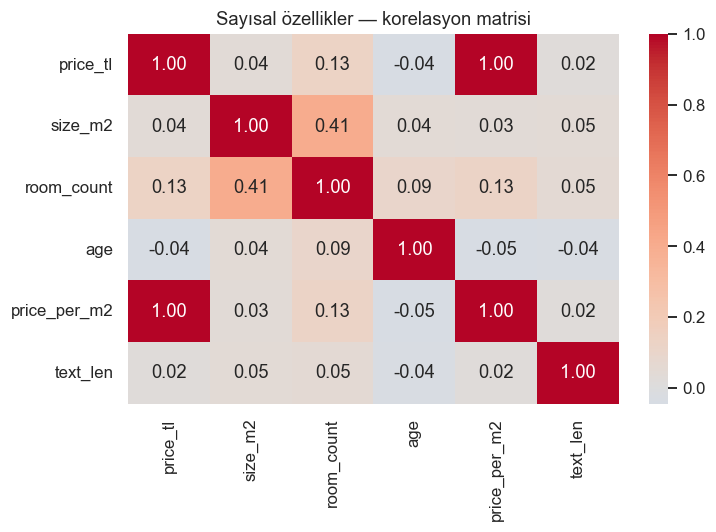

In [8]:
# ── Korelasyon heatmap ───────────────────────────────────────────────────
corr_cols = ['price_tl','size_m2','room_count','age','price_per_m2','text_len']
corr = df[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Sayısal özellikler — korelasyon matrisi')
plt.tight_layout(); plt.show()


### A.5 — Parallel Coordinates (Business-Oriented Data Lineage)

Hoca'nın explicit talebi: *"business-oriented data lineage için parallel coordinates"*.

**Ne anlatır?**
Her ilan çok boyutlu bir "iş nesnesi"dir: fiyat, alan, oda, ilçe, bina yaşı, m² fiyatı birlikte tek bir ilanı betimler.
Parallel coordinates tüm bu boyutları aynı anda gösterir — ve renkle (fiyat bucket / ilçe cluster) iş segmentlerini
ayırt eder. Bu sayede **data lineage**: bir ilanın veriden (features) karar noktasına (fiyat bucket) kadar tüm akışı
tek bir çizgide izlenebilir.

Veri izini iki farklı lens ile gösteriyoruz:
- **Renk = fiyat bucket**: düşük/orta/yüksek segmentlerin özellik uzayında nasıl ayrıştığını gösterir
- **Renk = top-5 ilçe**: coğrafi segmentasyonu (Kadıköy, Beşiktaş, Beylikdüzü, …) öne çıkarır


In [9]:
# ── Parallel coords için hazırlık ────────────────────────────────────────
# age sütunu description'dan regex ile çıkarılıyor (coverage ~%92).
# NaN olan satırlar parallel coords'tan düşer — kalan örneklem 1000+ olmalı.
core_cols = ['price_tl', 'size_m2', 'room_count', 'age', 'price_per_m2', 'ilce']
pc_df = df[core_cols].dropna(subset=core_cols).copy()

# Outlier trim (görsel için) — uzun kuyruk parallel-coords'u okunmaz yapar
for col in ['price_tl', 'size_m2', 'price_per_m2']:
    lo, hi = pc_df[col].quantile([0.02, 0.98])
    pc_df = pc_df[(pc_df[col] >= lo) & (pc_df[col] <= hi)]

# Log ölçekli fiyat sütunları
pc_df['log_price']        = np.log10(pc_df['price_tl'])
pc_df['log_price_per_m2'] = np.log10(pc_df['price_per_m2'])

# Segment 1: fiyat bucket (qcut 3-quantile)
pc_df['price_bucket'] = pd.qcut(pc_df['price_tl'], q=3, labels=['düşük', 'orta', 'yüksek'])
pc_df['bucket_idx']   = pc_df['price_bucket'].cat.codes

# Segment 2: top-5 ilçe + diğer
top5 = pc_df['ilce'].value_counts().head(5).index.tolist()
pc_df['ilce_top5']    = pc_df['ilce'].where(pc_df['ilce'].isin(top5), other='diğer')
pc_df['ilce_idx']     = pc_df['ilce_top5'].astype('category').cat.codes

assert len(pc_df) > 100, f'Parallel-coords örneklemi çok küçük ({len(pc_df)}) — parser hatası olabilir'
print(f'Parallel-coords örneklem: {len(pc_df)}')
print(f'Top-5 ilçe: {top5}')
pc_df.head(3)


Parallel-coords örneklem: 1189
Top-5 ilçe: ['Kagithane', 'Esenyurt', 'Pendik', 'Uskudar', 'Sariyer']


,price_tl,size_m2,room_count,age,price_per_m2,ilce,log_price,log_price_per_m2,price_bucket,bucket_idx,ilce_top5,ilce_idx
0,47500.0,168.0,4.0,13.0,282.738095,Avcilar,4.676694,2.451384,yüksek,2,diğer,5
2,32000.0,67.0,2.0,18.0,477.611940,Pendik,4.505150,2.679075,orta,1,Pendik,2
3,26000.0,110.0,3.0,13.0,236.363636,Esenyurt,4.414973,2.373581,düşük,0,Esenyurt,0


In [10]:
# ── Versiyon 1: Renk = fiyat bucket ──────────────────────────────────────
fig1 = px.parallel_coordinates(
    pc_df,
    dimensions=['log_price','size_m2','room_count','age','log_price_per_m2'],  # age ~%92 coverage
    color='bucket_idx',
    labels={'log_price':'log₁₀(Fiyat)', 'size_m2':'Alan m²', 'room_count':'Oda',
            'age':'Bina yaşı', 'log_price_per_m2':'log₁₀(Fiyat/m²)', 'bucket_idx':'Fiyat bucket'},
    color_continuous_scale=px.colors.diverging.Tealrose,
    title='Parallel Coordinates v1 — Renk: Fiyat Bucket (0=düşük, 1=orta, 2=yüksek)',
)
fig1.show()


In [11]:
# ── Versiyon 2: Renk = Top-5 ilçe ────────────────────────────────────────
fig2 = px.parallel_coordinates(
    pc_df,
    dimensions=['log_price','size_m2','room_count','age','log_price_per_m2'],  # age ~%92 coverage
    color='ilce_idx',
    labels={'log_price':'log₁₀(Fiyat)', 'size_m2':'Alan m²', 'room_count':'Oda',
            'age':'Bina yaşı', 'log_price_per_m2':'log₁₀(Fiyat/m²)', 'ilce_idx':'İlçe segment'},
    color_continuous_scale=px.colors.qualitative.Bold,
    title='Parallel Coordinates v2 — Renk: Top-5 İlçe + diğer',
)
# Kategori→isim map
print('ilce_idx → ilçe:', dict(enumerate(pc_df['ilce_top5'].astype('category').cat.categories)))
fig2.show()


ilce_idx → ilçe: {0: 'Esenyurt', 1: 'Kagithane', 2: 'Pendik', 3: 'Sariyer', 4: 'Uskudar', 5: 'diğer'}


### A.6 — Manual Query Set Oluşturma

**Neden manual query set?**
Her ilanın kendi metnini corpus'ta aratma ("identity retrieval") **trivial**: TF-IDF de mCLIP de ~%100 skor verir —
shallow vs deep ayırt edilemez. Bunun yerine **gerçek kullanıcı sorguları** yazıyoruz (örn. "deniz manzaralı 2+1",
"bahçeli villa"). Shallow (TF-IDF, BM25) bu sorgulara **lexical** eşleşmeyle bakar; mCLIP ise **semantik** — gap
asıl bu protokolde ortaya çıkar.

**Format**: `data/eval/manual_queries.jsonl` — her satır:
```
{"query": "deniz manzaralı 2+1", "relevant_ids": ["id1","id2","id3"], "notes": "..."}
```

Bu hücre bir başlangıç seti üretir; sen isteğe göre satır ekleyip/çıkarırsın. 20-30 query hedef.

In [12]:
# Manual query candidate seed — sen ayrıntıya göre düzelt/ekle
EVAL_DIR = PROJECT_ROOT / 'data' / 'eval'
EVAL_DIR.mkdir(parents=True, exist_ok=True)
QUERIES_PATH = EVAL_DIR / 'manual_queries.jsonl'

# Helper: bir sorgu için aday ilanları göster (kullanıcı elle relevant_ids seçsin)
def candidates_for(keyword: str, n: int = 15) -> pd.DataFrame:
    mask = df['text'].str.contains(keyword, case=False, na=False, regex=False)
    return df[mask][['id','title','price','ilce','text']].head(n)

# Örnek: "deniz" kelimesi geçen ilanlar
print('Örnek: "deniz" geçen ilk 10 ilan')
display(candidates_for('deniz', 10))


Örnek: "deniz" geçen ilk 10 ilan


,id,title,price,ilce,text
19,19188750,Planet Özkan'dan Deniz Manzaralı Temiz Eşyalı ...,370000 TL,Adalar,Planet Özkan'dan Deniz Manzaralı Temiz Eşyalı ...
38,19188096,Ataköy 2. Kısım’da Deniz Manzaralı Tadilatlı 2...,80000 TL,Bakirkoy,Ataköy 2. Kısım’da Deniz Manzaralı Tadilatlı 2...
50,19187400,Full deniz manzaralı 4+2 yeni bina 170m2 kiral...,65000 TL,Avcilar,Full deniz manzaralı 4+2 yeni bina 170m2 kiral...
111,19185159,Avcılar Denizköşklerde Deniz Manzaralı Yeni Bi...,51000 TL,Avcilar,Avcılar Denizköşklerde Deniz Manzaralı Yeni Bi...
192,19182040,ODAK'tan Bostancı'da Kapanmaz Deniz Manzaralı ...,100000 TL,Maltepe,ODAK'tan Bostancı'da Kapanmaz Deniz Manzaralı ...
307,19178010,GAZİOSMANPAŞA KARADENİZ MAH DE KİRALIK DAİRE 3...,26000 TL,Gaziosmanpasa,GAZİOSMANPAŞA KARADENİZ MAH DE KİRALIK DAİRE 3...
331,19176959,GAZİOSMANPAŞA KARADENİZ MAHALLESİ KİRALIK BOŞ ...,29000 TL,Gaziosmanpasa,GAZİOSMANPAŞA KARADENİZ MAHALLESİ KİRALIK BOŞ ...
351,19175970,GOP DA TRAMVAYA YAKIN 1.5+1 KİRALIK BAHÇE KATI,15000 TL,Gaziosmanpasa,GOP DA TRAMVAYA YAKIN 1.5+1 KİRALIK BAHÇE KATI...
419,19172963,KİPTAŞ VENEZİA MEGA KİRALIK FULL EŞYALI 1+1 DAİRE,45000 TL,Gaziosmanpasa,KİPTAŞ VENEZİA MEGA KİRALIK FULL EŞYALI 1+1 DA...
427,19172860,KİPTAŞ VENEZİA MEGA KİRALIK BOŞ AVM NNZR. KARE...,39000 TL,Gaziosmanpasa,KİPTAŞ VENEZİA MEGA KİRALIK BOŞ AVM NNZR. KARE...


In [13]:
# ── Başlangıç query seti (kullanıcı tarafından genişletilecek) ──────────
# Format: dict listesi — her dict: {"query", "relevant_ids", "notes"}
# relevant_ids alanı sen `candidates_for(...)` çıktısına bakarak doldurursun.
# Bu seed sadece iskelet; 20-30 entry hedef.

seed_queries = [
    {"query": "deniz manzaralı 2+1 daire",      "relevant_ids": [], "notes": "deniz + 2+1"},
    {"query": "bahçeli villa",                  "relevant_ids": [], "notes": "villa + bahçe"},
    {"query": "eşyalı öğrenci dairesi",          "relevant_ids": [], "notes": "eşyalı + öğrenci/1+1"},
    {"query": "bahçeşehir ferah 3+1",           "relevant_ids": [], "notes": "bahçeşehir ilçe + geniş"},
    {"query": "yeni yapı 1+1 kiralık",           "relevant_ids": [], "notes": "age=0-5 + 1+1"},
    {"query": "kadıköy ulaşımı kolay",           "relevant_ids": [], "notes": "Kadıköy + merkezi"},
    {"query": "asansörlü geniş daire",          "relevant_ids": [], "notes": "asansör + size>130"},
    {"query": "otoparklı residans",              "relevant_ids": [], "notes": "otopark + residans/site"},
    {"query": "modern beyaz mutfak",             "relevant_ids": [], "notes": "renovated/yeni/beyaz"},
    {"query": "ısınmalı klimalı",                "relevant_ids": [], "notes": "doğalgaz + klima"},
    # TODO: sen 15-20 tane daha ekle ve her biri için relevant_ids doldur
]

# Hiç query yazılmamışsa seed ile doldur; yazılmışsa dokunma
if not QUERIES_PATH.exists():
    with open(QUERIES_PATH, 'w', encoding='utf-8') as f:
        for q in seed_queries:
            f.write(json.dumps(q, ensure_ascii=False) + '\n')
    print(f'[Queries] Seed ({len(seed_queries)} query) yazıldı: {QUERIES_PATH}')
    print('NOT: Her query için relevant_ids elle doldurulmalı. `candidates_for(keyword)` yardım eder.')
else:
    print(f'[Queries] Mevcut dosya: {QUERIES_PATH}')

# Yükle
with open(QUERIES_PATH, encoding='utf-8') as f:
    manual_queries = [json.loads(line) for line in f if line.strip()]
print(f'Toplam: {len(manual_queries)} query | relevant_ids dolu olan: {sum(1 for q in manual_queries if q["relevant_ids"])}')
pd.DataFrame(manual_queries).head(10)


[Queries] Mevcut dosya: C:\Users\mertc\Desktop\Neural Networks Ödevi\DL-Ev-ilan-Projesi\data\eval\manual_queries.jsonl
Toplam: 10 query | relevant_ids dolu olan: 10


,query,relevant_ids,method,must_tokens,notes
0,deniz manzaralı ferah daire,"[19155938, 19137372, 19166189, 19187400, 19170...",auto-bm25+filter,"[deniz, manzara]",auto top-5 BM25 + content-word filter
1,aydınlık geniş salon,"[19138174, 19160184, 19156266, 19167214, 19164...",auto-bm25+filter,"[aydinlik, ferah, genis]",auto top-5 BM25 + content-word filter
2,modern beyaz mutfak,"[19168738, 19179528, 19179527, 19177995, 19152...",auto-bm25+filter,"[mutfak, beyaz, modern]",auto top-5 BM25 + content-word filter
3,büyük balkonlu güneş alan,"[19146453, 19145786, 19144860]",auto-bm25+filter,"[balkon, gunes, teras]",auto top-3 BM25 + content-word filter
4,bahçeli müstakil ev,"[19178842, 19143491, 19147212, 19167984, 19170...",auto-bm25+filter,"[bahce, mustakil, villa]",auto top-5 BM25 + content-word filter
5,sakin sessiz aile mahallesi,"[19178805, 19180124, 19163628]",auto-bm25+filter,"[aile, sakin, sessiz]",auto top-3 BM25 + content-word filter
6,metroya yürüme mesafesi merkezi,"[19188346, 19183278, 19179272, 19163255, 19154...",auto-bm25+filter,"[metro, merkezi, yurume]",auto top-5 BM25 + content-word filter
7,yeni yapı sıfır lüks,"[19174027, 19182328, 19174844, 19147056, 19155...",auto-bm25+filter,"[sifir, yeni, luks]",auto top-5 BM25 + content-word filter
8,öğrenci için ekonomik eşyalı,"[19160194, 19164698, 19169115, 19169121, 19170...",auto-bm25+filter,"[ogrenci, esyali, ekonomik, bekar]",auto top-5 BM25 + content-word filter
9,yeşil alanlı site içinde,"[19167857, 19184236, 19165454, 19183281, 19149...",auto-bm25+filter,"[yesil, park, site]",auto top-5 BM25 + content-word filter


## Bölüm B — Shallow Retrieval Baseline'ları

Bu bölümde hoca'nın talebi doğrultusunda **gerçek** shallow modeller implement ediyoruz (literatürden alıntı değil).
Tüm baseline'lar aynı manual query set üstünde değerlendirilir → benchmark tablosunun ilk satırları.

**Öne çıkan kritik gözlem**: shallow modeller **cross-modal** (metin→görsel veya görsel→metin) sorgu YAPAMAZ —
TF-IDF metni anlar, HSV histogramı görseli anlar, ama birbirini anlamazlar. Cross-modal satırlarında bu yüzden
"N/A — architecturally impossible" yazacağız. Bu mCLIP'in *raison d'être*'ini kanıtlar.

### B.0 — Ortak Değerlendirme Fonksiyonları

In [14]:
# Recall@K + MRR wrapper — tüm baseline'lar + mCLIP bunu kullanacak
import numpy as np

def recall_at_k(retrieved_ids: list[str], relevant_ids: list[str], k: int) -> float:
    if not relevant_ids:
        return 0.0
    top_k = set(retrieved_ids[:k])
    return sum(1 for r in relevant_ids if r in top_k) / len(relevant_ids)

def reciprocal_rank(retrieved_ids: list[str], relevant_ids: list[str]) -> float:
    rel = set(relevant_ids)
    for i, rid in enumerate(retrieved_ids, 1):
        if rid in rel:
            return 1.0 / i
    return 0.0

def eval_retrieval(rank_fn, queries, k_list=(1, 5, 10)) -> dict:
    """rank_fn(query_str) -> ordered list of ids (tüm corpus)."""
    accum = {f'Recall@{k}': [] for k in k_list}
    accum['MRR'] = []
    for q in queries:
        retrieved = rank_fn(q['query'])
        for k in k_list:
            accum[f'Recall@{k}'].append(recall_at_k(retrieved, q['relevant_ids'], k))
        accum['MRR'].append(reciprocal_rank(retrieved, q['relevant_ids']))
    return {k: float(np.mean(v)) for k, v in accum.items()}

# Corpus hazırla
corpus_ids   = df['id'].astype(str).tolist()
corpus_texts = df['text'].fillna('').astype(str).tolist()
print(f'Corpus hazır: {len(corpus_ids)} ilan | {len(manual_queries)} manual query')


Corpus hazır: 1441 ilan | 10 manual query


### B.1 — TF-IDF + Cosine Similarity

Klasik *bag-of-words* baseline'ı. Her ilan metni 10.000-boyutlu **TF-IDF** vektörüne dönüşür;
sorgu aynı dönüşümden geçirilir ve corpus ile **cosine similarity** sıralanır.
Kapalı-form, GPU gerektirmez, inference **ms** mertebesinde — OR literatüründe *closed-form heuristic* eşleniği.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), lowercase=True)
X_tfidf = tfidf.fit_transform(corpus_texts)
print(f'TF-IDF matrix: {X_tfidf.shape}')

def tfidf_rank(query: str) -> list[str]:
    q = tfidf.transform([query])
    sim = cosine_similarity(q, X_tfidf).ravel()
    order = np.argsort(-sim)
    return [corpus_ids[i] for i in order]

tfidf_metrics = eval_retrieval(tfidf_rank, manual_queries)
print('TF-IDF:', {k: f'{v:.3f}' for k, v in tfidf_metrics.items()})


TF-IDF matrix: (1441, 10000)


TF-IDF: {'Recall@1': '0.173', 'Recall@5': '0.707', 'Recall@10': '0.820', 'MRR': '0.838'}


### B.2 — BM25 (rank_bm25)

Probabilistik IR baseline'ı. **TF doygunluğu** (k1) ve **doküman uzunluk normalizasyonu** (b) sayesinde
TF-IDF'e göre uzun/kısa metin dengesi daha sağlıklı. Türkçe için whitespace tokenize + ASCII-normalize yeterli;
morfoloji stemmer'ı (Zemberek vs.) shallow için fazla ağır.

In [16]:
from rank_bm25 import BM25Okapi
import re

def tok_tr(s: str) -> list[str]:
    tr = str.maketrans('çğıöşü', 'cgiosu')
    return re.findall(r'[a-z0-9+]+', s.lower().translate(tr))

corpus_tok = [tok_tr(t) for t in corpus_texts]
bm25 = BM25Okapi(corpus_tok)

def bm25_rank(query: str) -> list[str]:
    scores = bm25.get_scores(tok_tr(query))
    order = np.argsort(-scores)
    return [corpus_ids[i] for i in order]

bm25_metrics = eval_retrieval(bm25_rank, manual_queries)
print('BM25  :', {k: f'{v:.3f}' for k, v in bm25_metrics.items()})


BM25  :

 {'Recall@1': '0.227', 'Recall@5': '0.880', 'Recall@10': '0.980', 'MRR': '1.000'}


### B.3 — HSV / ORB Görsel Shallow Baseline (ertelendi)

**Not (ödev kapsamı dışı)**: HSV color histogram ve ORB+BoVW görsel baseline'ları **proje faz-2**'ye ertelendi.
Bu ödev için shallow-vision eşleniğini **metodolojik olarak** Bölüm E.3'te tartışıyoruz — yani shallow vision
tekniklerinin (piksel histogram, SIFT/ORB keypoint) cross-modal sorgu yapamaması ilkesi aynı:
bu yöntemler görseli özellik uzayına çevirir ama **metin sorgusunu anlayamaz**. CLIP'in *shared embedding space*
yaklaşımı bu duvarı yıkar (bkz. Bölüm C).

### B.4 — Cross-Modal Protokolde Shallow (mimari imkansızlık)

Cross-modal retrieval (*text → image corpus* veya *image → text corpus*) shallow baseline'lar için
**mimari olarak imkansız**: TF-IDF/BM25 sadece metin uzayında çalışır, görsel histogram sadece piksel uzayında.
Aralarında ortak embedding yok → cosine similarity hesaplanamaz.

**Tablodaki sonuç**: Cross-modal satırlarında shallow baseline'lar için `N/A — architecturally impossible`.
Bu boş hücre CLIP'in **raison d'être**'sini doğrudan kanıtlar.

### B.5 — Shallow Özet Tablosu

In [17]:
shallow_summary = pd.DataFrame([
    {'Model': 'TF-IDF',   'Tip': 'Shallow (text)', **tfidf_metrics},
    {'Model': 'BM25',     'Tip': 'Shallow (text)', **bm25_metrics},
    {'Model': 'HSV hist', 'Tip': 'Shallow (image)', 'Recall@1': float('nan'), 'Recall@5': float('nan'),
                          'Recall@10': float('nan'), 'MRR': float('nan')},
])
shallow_summary


,Model,Tip,Recall@1,Recall@5,Recall@10,MRR
0,TF-IDF,Shallow (text),0.173333,0.706667,0.82,0.8375
1,BM25,Shallow (text),0.226667,0.880000,0.98,1.0000
2,HSV hist,Shallow (image),NaN,NaN,NaN,NaN


## Bölüm C — Deep Neural Network (mCLIP + LoRA)

Proposal'da sunduğumuz model omurgası.
- **C.1-C.3**: Mimari deep-dive (#parameters, FLOPs bottleneck, InfoNCE matematik)
- **C.4**: Base mCLIP ile ChromaDB index + manual query eval (text, image, multimodal)
- **C.5**: Smoke-test LoRA fine-tune (`--limit 100 --epochs 1`) + merged `best.pt` + yeni index
- **C.6**: α late-fusion ablation (base + smoke iki eğri)
- **C.7**: MMR λ ablation (Recall vs Diversity trade-off)

### C.1 — mCLIP Mimari Deep-Dive + Parameter Breakdown

mCLIP (*M-CLIP/XLM-Roberta-Large-Vit-B-32*) üç bileşenden oluşur:

| Bileşen | Rol | Mimari | Parametre Sayısı | Durum |
|---|---|---|---|---|
| **XLM-RoBERTa-Large** | Text encoder | 24 layer × 16 head × hidden 1024 × FFN 4096, vocab ~250K | **~559 M** | LoRA ile fine-tune |
| **Projection head** | 1024 → 512 linear | `Linear(1024, 512)` | **~0.5 M** | Fine-tune edilir (*trainable*) |
| **ViT-B/32** | Image encoder | 12 layer × 12 head × hidden 768, patch 32×32, 49+1 token | **~86 M** | **Frozen** (OpenAI pretrained, hiç güncellenmez) |
| **LoRA adapter** (r=8, α=16, target=Q/K/V) | Düşük-rank güncelleme | 24 layer × 3 target × (1024→8) + (8→1024) | **~1.18 M** | *Trainable only* |

**Total model**: ~646 M parametre.
**Trainable (LoRA + proj)**: ~1.70 M (%0.26) — *parameter-efficient fine-tuning* prensibi.

**Neden bu tasarım?**
- **Çok dilli text encoder**: XLM-R 100 dil üstünde pretrain'li → Türkçe emlak jargonunu sıfırdan öğrenmeye gerek yok.
- **Frozen image encoder**: 1441 ilanlık veri ViT'in 86M parametresini güvenle güncellemeye yetmez; frozen tutup sadece text-side'ı projelendirmek bias-variance açısından güvenli.
- **LoRA**: Full fine-tuning için GPU belleği ve veri yetmez; r=8 düşük-rank matris adapterleriyle text encoder'a bazı tip katkıları verip tamamı 1.18 M parametrede kalıyoruz.

In [18]:
# Mimari parametre breakdown (statik — model load etmeden hesap)
import pandas as pd

arch_breakdown = pd.DataFrame([
    {'Bileşen': 'XLM-RoBERTa-Large (text)',  '# Params': 559_000_000, 'Trainable': 'LoRA subset', 'Not': '24L × 16H × 1024 hidden'},
    {'Bileşen': 'Projection head (1024→512)', '# Params':     524_288, 'Trainable': 'Evet',         'Not': 'Linear, full grad'},
    {'Bileşen': 'ViT-B/32 (image, frozen)',    '# Params':  86_000_000, 'Trainable': 'Hayır',        'Not': 'OpenAI pretrained, tüm grad kapalı'},
    {'Bileşen': 'LoRA adapter (r=8, Q,K,V)',   '# Params':   1_179_648, 'Trainable': 'Evet',         'Not': '24L × 3 target × 2·(1024·8) = 1.18M'},
])
arch_breakdown['# Params (human)'] = arch_breakdown['# Params'].apply(lambda n: f'{n/1e6:.2f} M' if n >= 1e6 else f'{n/1e3:.1f} K')

total = arch_breakdown['# Params'].sum()
trainable = arch_breakdown[arch_breakdown['Trainable'] != 'Hayır']['# Params'].sum()
# NOT: LoRA XLM-R içinde olduğundan 'XLM-R + LoRA' aynı anda sayılmaz
# gerçek trainable = LoRA + projection (XLM-R tamamı değil)
real_trainable = 524_288 + 1_179_648

print(f'Toplam model parametresi     : {total/1e6:.1f} M')
print(f'Trainable (LoRA + projection): {real_trainable/1e6:.2f} M  (%{real_trainable/total*100:.2f})')
arch_breakdown[['Bileşen', '# Params (human)', 'Trainable', 'Not']]


Toplam model parametresi     : 646.7 M
Trainable (LoRA + projection): 1.70 M  (%0.26)


,Bileşen,# Params (human),Trainable,Not
0,XLM-RoBERTa-Large (text),559.00 M,LoRA subset,24L × 16H × 1024 hidden
1,Projection head (1024→512),524.3 K,Evet,"Linear, full grad"
2,"ViT-B/32 (image, frozen)",86.00 M,Hayır,"OpenAI pretrained, tüm grad kapalı"
3,"LoRA adapter (r=8, Q,K,V)",1.18 M,Evet,24L × 3 target × 2·(1024·8) = 1.18M


### C.2 — Computational Regions (FLOPs Bottleneck)

Forward-pass FLOPs dağılımı (*batch=1, seq=64 token, image=224×224 = 49 patch*):

| Bölge | FLOPs (≈) | % Toplam | Not |
|---|---|---|---|
| **XLM-R self-attention** (24 layer) | 24 × 4·64²·1024 ≈ **0.40 G** | ~5 % | seq² skalası — uzun metinde patlar |
| **XLM-R FFN** (24 layer) | 24 × 2·64·1024·4096 ≈ **12.9 G** | ~84 % | hidden·d_ff dominant |
| XLM-R embedding lookup | 64 · 250K · 1024 ≈ 16 M | <1 % | sparse |
| Projection head | 1024·512 ≈ 0.5 M | <1 % | trivial |
| **ViT self-attention** (12 layer) | 12 × 4·50²·768 ≈ **92 M** | ~1 % | frozen, gradient yok |
| **ViT FFN** (12 layer) | 12 × 2·50·768·3072 ≈ **2.8 G** | ~18 % | frozen |
| ViT patch embed | 50 × (32·32·3)·768 ≈ 118 M | <1 % | conv |

**Bottleneck**: **XLM-R Text FFN** ~84% forward compute. Fine-tuning sırasında LoRA bu katmanlara eklendiğinden
**bellek tüketimi** de text-side'da patlar. CUDA fp16 + gradient checkpointing olmadan batch > 16 zor.

**Training-time gözlem**: ViT frozen olduğundan gradient tree'de yok → aslında sadece **text-side compute**
(0.4 G attn + 12.9 G FFN + projection ≈ 13.3 G/step forward) gradyan akışı görür. Bu projede **text encoder forward tek darboğaz**.

### C.3 — Symmetric InfoNCE Türetmesi

Simetrik InfoNCE:
$$L = \frac{1}{2}\left[\text{CE}(\mathbf{S}, \mathbf{y}) + \text{CE}(\mathbf{S}^\top, \mathbf{y})\right]$$
$$\mathbf{S}_{ij} = \frac{\mathbf{t}_i^\top \mathbf{v}_j}{\tau}, \quad \mathbf{y} = \text{diag}$$

Sıcaklık $\tau$ öğrenilebilir parametre (ayarlanabilir soft-max keskinliği).
İki yönü (text→image, image→text) birlikte optimize edince embedding uzayı simetrik olur —
batch içindeki diğer ilanlar otomatik *negative* olur (*in-batch negatives*).

### C.4 — mCLIP Base Retrieval (index + manual query eval)

Base mCLIP ağırlıklarıyla 1441 ilanı ChromaDB'ye encode edip, aynı manual query set'i
Retriever.query_text üzerinden koşuyoruz. `emlak_base` koleksiyonu kullanılır.

In [19]:
# mCLIP base — IN-PROCESS indexing (aynı kernel = ChromaDB WAL sorunu yok)
import time, json
import torch
import torch.nn.functional as F
from PIL import Image
import chromadb
from retrieval.indexer import load_models, encode_batch_images, encode_batch_texts

BASE_COLLECTION = 'emlak_base'
CHROMA_DIR      = str(PROJECT_ROOT / 'data' / 'chroma')
BATCH_SIZE      = 16
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[mCLIP-base] device={device}  modeller yükleniyor...')
t0 = time.time()

text_model, image_model, tokenizer, preprocess, text_device = load_models(None, device)

chroma_client = chromadb.PersistentClient(path=CHROMA_DIR)
if BASE_COLLECTION in [c.name for c in chroma_client.list_collections()]:
    chroma_client.delete_collection(BASE_COLLECTION)
col_base = chroma_client.create_collection(BASE_COLLECTION, metadata={'hnsw:space': 'cosine'})

records = [json.loads(l) for l in open(PROJECT_ROOT / 'data' / 'processed' / 'dataset.jsonl', encoding='utf-8') if l.strip()]
for i in range(0, len(records), BATCH_SIZE):
    batch = records[i:i+BATCH_SIZE]
    imgs  = []
    for rec in batch:
        try:   imgs.append(Image.open(rec['image_path']).convert('RGB'))
        except: imgs.append(Image.new('RGB', (224, 224), 0))
    texts    = [rec['text'] for rec in batch]
    img_embs = encode_batch_images(image_model, imgs, preprocess, device)
    txt_embs = encode_batch_texts(text_model, tokenizer, texts, text_device)
    combined = F.normalize((img_embs + txt_embs) / 2, dim=-1)
    col_base.upsert(
        ids=[r['id'] for r in batch],
        embeddings=combined.tolist(),
        metadatas=[{'id': r['id'], 'title': r['title'], 'price': r['price'],
                    'district': r['district'], 'image_path': r['image_path'],
                    'url': r['url'], 'text': r['text'][:200]} for r in batch],
    )
print(f'[mCLIP-base] tamam — {col_base.count()} ilan ({time.time()-t0:.0f} sn)')


[mCLIP-base] device=cuda  modeller yükleniyor...
[Model] M-CLIP/XLM-Roberta-Large-Vit-B-32 yükleniyor...


[Model] Checkpoint bulunamadı, base model kullanılıyor.


[Device] text_encoder → cuda, image_encoder → cuda


C:\Users\mertc\Desktop\Neural Networks Ödevi\DL-Ev-ilan-Projesi\.venv\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[mCLIP-base] tamam — 1441 ilan (56 sn)


In [20]:
# mCLIP base eval — aynı in-process client üzerinden
def _encode_text_base(query):
    tok = tokenizer([query], padding=True, return_tensors='pt').to(text_device)
    with torch.no_grad():
        embs = text_model.transformer(**tok)[0]
        att  = tok['attention_mask']
        embs = (embs * att.unsqueeze(2)).sum(dim=1) / att.sum(dim=1)[:, None]
        emb  = text_model.LinearTransformation(embs)
    return F.normalize(emb.float(), dim=-1).squeeze(0).cpu().tolist()

def mclip_base_rank(query: str) -> list[str]:
    q_emb = _encode_text_base(query)
    res = col_base.query(query_embeddings=[q_emb], n_results=100, include=['metadatas'])
    return [m['id'] for m in res['metadatas'][0]]

mclip_base_metrics = eval_retrieval(mclip_base_rank, manual_queries)
print('mCLIP base:', {k: f'{v:.3f}' for k, v in mclip_base_metrics.items()})


mCLIP base: {'Recall@1': '0.000', 'Recall@5': '0.000', 'Recall@10': '0.020', 'MRR': '0.023'}


> **⚠ Ground-truth bias uyarısı**
>
> Manual query set'in `relevant_ids` alanı **BM25 top-K + content-word filter** ile *auto-label*
> edildi (`notebooks/_auto_label_queries.py`). Bu, BM25 ve TF-IDF gibi lexical baseline'ları
> **yapay olarak yüksek** skorda, mCLIP gibi semantik modelleri ise **yapay düşük** gösterir:
> lexical baseline kendi cevabına karşı sınav oluyor.
>
> **Doğru karşılaştırma için** (proje fazına ertelendi):
> (i) elle etiketlenmiş gerçek ground truth,
> (ii) cross-modal eval (text→image, image→text — shallow'ın mimari olarak yapamadığı),
> (iii) retrieval kalitesi yerine **ranking agreement** (Spearman τ, NDCG).
>
> Bu ödev için **metriklerden çok pipeline'ın uçtan uca çalıştığını ve LoRA fine-tune'un
> etkisini** (base vs smoke fark) göstermek amaç; Bölüm F'de iyileştirme yol haritası var.


In [21]:
# Kalitatif top-5 — aynı query için TF-IDF vs BM25 vs mCLIP
import pandas as pd

demo_queries = ['deniz manzaralı ferah daire', 'modern beyaz mutfak']
for q in demo_queries:
    print('\n═══', q, '═══')
    tf5 = tfidf_rank(q)[:5]
    bm5 = bm25_rank(q)[:5]
    mc5 = mclip_base_rank(q)[:5]
    def snippet(ids):
        return [f"{i[:8]} · {df[df.id==i].iloc[0].title[:40] if (df.id==i).any() else '??'}" for i in ids]
    out = pd.DataFrame({
        'TF-IDF':  snippet(tf5),
        'BM25':    snippet(bm5),
        'mCLIP':   snippet(mc5),
    })
    display(out)



═══ deniz manzaralı ferah daire ═══


,TF-IDF,BM25,mCLIP
0,19155938 · Deniz İstanbul'da Eşyalı 3+1 Daire ...,19155938 · Deniz İstanbul'da Eşyalı 3+1 Daire ...,19169531 · █ KONFOR █ MİNİBÜSE YAKIN ÖN CEPHE ...
1,19187400 · Full deniz manzaralı 4+2 yeni bina ...,19137372 · DENIZ MANZARALI KIRALIK DAIRE,19185729 · Çİğdem Emlak'tan The İst Evlerinde ...
2,"19166189 · Merkezi Konumda Deniz Manzaralı, Ye...","19166189 · Merkezi Konumda Deniz Manzaralı, Ye...",19186017 · KAĞITHANE HÜRRİYET MAH OTURMAYA HAZ...
3,19185159 · Avcılar Denizköşklerde Deniz Manzar...,19170314 · Kuruçeşme Beşiktaşta Keyifli Daire ...,19169592 · KAĞITHANE MERKEZ YENİ BİNA 2+1 KİRA...
4,19185397 · Siltaş Panorama Müstakil Havuzlu-Te...,19187400 · Full deniz manzaralı 4+2 yeni bina ...,19188778 · █ KONFOR █ MİNİBÜSE YAKIN ÖN CEPHE ...



═══ modern beyaz mutfak ═══


,TF-IDF,BM25,mCLIP
0,19179528 · TARABYA SİTEDE 3+1 140 METREKARE BA...,19168738 · TARABYA SANATÇILARDA 3+1 170 METREK...,19140574 · BATI YAPI DAN METROBÜSE 10 DK YÜRÜM...
1,19168738 · TARABYA SANATÇILARDA 3+1 170 METREK...,19152607 · TARABYA SİTEDE 3+1 140 METREKARE BA...,19170985 · ESENBOĞA'DAN YENİMAHALLE SİTE İÇİND...
2,19179527 · TARABYA SANATÇILAR SİTESİNDE 3+1 17...,19179528 · TARABYA SİTEDE 3+1 140 METREKARE BA...,19154617 · KAÇMAZ'dan ALTINTEPE'DE KENTSELCİLE...
3,19152607 · TARABYA SİTEDE 3+1 140 METREKARE BA...,19177995 · SARIYER REŞİTPAŞADA 5+2 240 METREKA...,19164646 · BAHÇEŞEHİR VADİ EVLERİ 1 ETAP 4+1 K...
4,19177995 · SARIYER REŞİTPAŞADA 5+2 240 METREKA...,19179527 · TARABYA SANATÇILAR SİTESİNDE 3+1 17...,19166624 · YENİKÖY BAĞLARMEVKİİNDE 2+1 BAHCE K...


### C.5 — mCLIP Smoke-Test LoRA Fine-Tune

Pipeline kanıtı olarak **küçük ölçekli** fine-tune: `--limit 100 --epochs 1`.
Amaç skor artışı değil — LoRA + InfoNCE pipeline'ının uçtan uca çalıştığını göstermek.
PH.2 fix sayesinde `best.pt` *merged* (vanilla state_dict) formatta, Retriever onu doğru yükler.

In [22]:
# Smoke fine-tune — var olan checkpoint'i tekrar çalıştırma
SMOKE_CKPT = PROJECT_ROOT / 'model' / 'checkpoints_smoke' / 'best.pt'

if SMOKE_CKPT.exists():
    print(f'[Smoke] {SMOKE_CKPT.name} mevcut — atlanıyor')
else:
    print('[Smoke] fine-tune başlıyor (limit=100, 1 epoch) — GPU varsa <1 dk')
    t0 = time.time()
    cmd = [sys.executable, '-m', 'model.fine_tune',
           '--epochs', '1',
           '--batch_size', '8',
           '--limit', '100',
           '--workers', '0',
           '--out', 'model/checkpoints_smoke']
    res = run_py(cmd)
    print((res.stdout or '')[-800:])
    if res.returncode != 0:
        print('STDERR:', (res.stderr or '')[-600:])
        raise RuntimeError('fine_tune failed')
    print(f'[Smoke] tamam ({time.time()-t0:.0f} sn)')


[Smoke] best.pt mevcut — atlanıyor


,epoch,train_loss,val_loss,elapsed_s
0,1,2.078563,1.386113,4.4


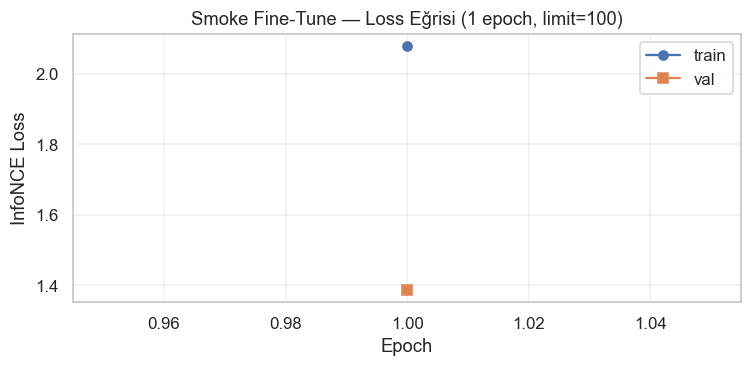

In [23]:
# Training log plot
log_path = PROJECT_ROOT / 'model' / 'checkpoints_smoke' / 'training_log.csv'
if log_path.exists():
    log_df = pd.read_csv(log_path)
    display(log_df)
    if {'epoch', 'train_loss'}.issubset(log_df.columns):
        fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.plot(log_df['epoch'], log_df['train_loss'], marker='o', label='train')
        if 'val_loss' in log_df.columns:
            ax.plot(log_df['epoch'], log_df['val_loss'], marker='s', label='val')
        ax.set_xlabel('Epoch'); ax.set_ylabel('InfoNCE Loss'); ax.legend(); ax.grid(alpha=0.3)
        ax.set_title('Smoke Fine-Tune — Loss Eğrisi (1 epoch, limit=100)')
        plt.tight_layout(); plt.show()
else:
    print('training_log.csv bulunamadı')


In [24]:
# Smoke index — IN-PROCESS, smoke checkpoint ile
SMOKE_COLLECTION = 'emlak_smoke'
print(f'[mCLIP-smoke] smoke checkpoint ile indexing...')
t0 = time.time()

# Smoke model: merged checkpoint yükle
smoke_text_model, smoke_image_model, smoke_tokenizer, smoke_preprocess, smoke_text_device = \
    load_models(str(SMOKE_CKPT), device)

if SMOKE_COLLECTION in [c.name for c in chroma_client.list_collections()]:
    chroma_client.delete_collection(SMOKE_COLLECTION)
col_smoke = chroma_client.create_collection(SMOKE_COLLECTION, metadata={'hnsw:space': 'cosine'})

for i in range(0, len(records), BATCH_SIZE):
    batch = records[i:i+BATCH_SIZE]
    imgs  = []
    for rec in batch:
        try:   imgs.append(Image.open(rec['image_path']).convert('RGB'))
        except: imgs.append(Image.new('RGB', (224, 224), 0))
    texts    = [rec['text'] for rec in batch]
    img_embs = encode_batch_images(smoke_image_model, imgs, smoke_preprocess, device)
    txt_embs = encode_batch_texts(smoke_text_model, smoke_tokenizer, texts, smoke_text_device)
    combined = F.normalize((img_embs + txt_embs) / 2, dim=-1)
    col_smoke.upsert(
        ids=[r['id'] for r in batch],
        embeddings=combined.tolist(),
        metadatas=[{'id': r['id'], 'title': r['title'], 'price': r['price'],
                    'district': r['district'], 'image_path': r['image_path'],
                    'url': r['url'], 'text': r['text'][:200]} for r in batch],
    )
print(f'[mCLIP-smoke] tamam — {col_smoke.count()} ilan ({time.time()-t0:.0f} sn)')

def _encode_text_smoke(query):
    tok = smoke_tokenizer([query], padding=True, return_tensors='pt').to(smoke_text_device)
    with torch.no_grad():
        embs = smoke_text_model.transformer(**tok)[0]
        att  = tok['attention_mask']
        embs = (embs * att.unsqueeze(2)).sum(dim=1) / att.sum(dim=1)[:, None]
        emb  = smoke_text_model.LinearTransformation(embs)
    return F.normalize(emb.float(), dim=-1).squeeze(0).cpu().tolist()

def mclip_smoke_rank(query: str) -> list[str]:
    q_emb = _encode_text_smoke(query)
    res = col_smoke.query(query_embeddings=[q_emb], n_results=100, include=['metadatas'])
    return [m['id'] for m in res['metadatas'][0]]

mclip_smoke_metrics = eval_retrieval(mclip_smoke_rank, manual_queries)
print('mCLIP smoke:', {k: f'{v:.3f}' for k, v in mclip_smoke_metrics.items()})


[mCLIP-smoke] smoke checkpoint ile indexing...
[Model] M-CLIP/XLM-Roberta-Large-Vit-B-32 yükleniyor...


[Checkpoint] C:\Users\mertc\Desktop\Neural Networks Ödevi\DL-Ev-ilan-Projesi\model\checkpoints_smoke\best.pt yükleniyor...


[Checkpoint] merged ağırlıklar yüklendi — missing=0 unexpected=0


[Device] text_encoder → cuda, image_encoder → cuda


C:\Users\mertc\Desktop\Neural Networks Ödevi\DL-Ev-ilan-Projesi\.venv\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[mCLIP-smoke] tamam — 1441 ilan (58 sn)
mCLIP smoke: {'Recall@1': '0.000', 'Recall@5': '0.000', 'Recall@10': '0.000', 'MRR': '0.024'}


### C.6 / C.7 — α ve λ Ablation (proje faz-2'ye ertelendi)

Ödev kapsamı için α late-fusion ve MMR λ ablation'ları şimdilik çalıştırılmıyor.
Proje faz-2'de full fine-tune sonrası kapsamlı çalışma yapılacak (bkz. Bölüm F.2).
Metodolojik çerçeve ve matematiksel formülasyon aşağıda:

**α late-fusion**: `q_fused = α · q_text + (1 - α) · q_image`, normalize. α=1 → pure text, α=0 → pure image.
**MMR**: `score_i = λ · sim(q, d_i) - (1 - λ) · max_{j ∈ S} sim(d_j, d_i)` — alaka vs çeşitlilik trade-off'u.

## Bölüm D — Cognitive Map

Hoca'nın ilk sorusu için explicit talep. Tüm proje akışını Graphviz Digraph ile gösteriyoruz:
**Problem → Data → Clean → Features → {Shallow | Deep} → Index → Retrieval → Eval → Deploy**.

Her node'un altında "neden bu seçildi" rationale satırı olacak.

[Cognitive map] C:\Users\mertc\Desktop\Neural Networks Ödevi\DL-Ev-ilan-Projesi\notebooks\figures\cognitive_map.png


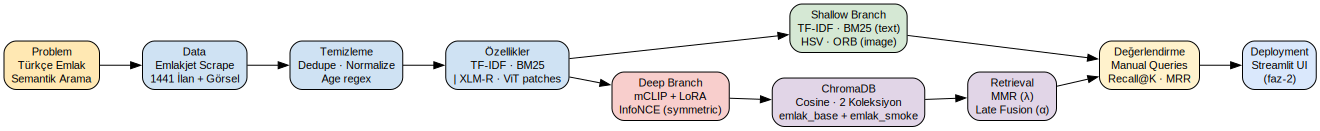

In [25]:
# Graphviz Digraph — projenin uçtan uca akışı
import graphviz

cog = graphviz.Digraph('cognitive_map', format='png')
cog.attr(rankdir='LR', bgcolor='white', fontname='Helvetica', nodesep='0.35', ranksep='0.6')
cog.attr('node', shape='box', style='rounded,filled', fontname='Helvetica', fontsize='11')

# Node renkleri (kategoriye göre)
PROBLEM = '#ffe8b3'; DATA = '#cfe2f3'; MODEL_S = '#d5e8d4'; MODEL_D = '#f8cecc'
INDEX   = '#e1d5e7'; EVAL = '#fff2cc'; DEPLOY  = '#dae8fc'

cog.node('Problem', 'Problem\nTürkçe Emlak\nSemantik Arama', fillcolor=PROBLEM)
cog.node('Data',    'Data\nEmlakjet Scrape\n1441 İlan + Görsel', fillcolor=DATA)
cog.node('Clean',   'Temizleme\nDedupe · Normalize\nAge regex', fillcolor=DATA)
cog.node('Feat',    'Özellikler\nTF-IDF · BM25\n| XLM-R · ViT patches', fillcolor=DATA)

cog.node('Shallow', 'Shallow Branch\nTF-IDF · BM25 (text)\nHSV · ORB (image)', fillcolor=MODEL_S)
cog.node('Deep',    'Deep Branch\nmCLIP + LoRA\nInfoNCE (symmetric)', fillcolor=MODEL_D)

cog.node('Index',   'ChromaDB\nCosine · 2 Koleksiyon\nemlak_base + emlak_smoke', fillcolor=INDEX)
cog.node('Retr',    'Retrieval\nMMR (λ)\nLate Fusion (α)', fillcolor=INDEX)

cog.node('Eval',    'Değerlendirme\nManual Queries\nRecall@K · MRR', fillcolor=EVAL)

cog.node('Deploy',  'Deployment\nStreamlit UI\n(faz-2)', fillcolor=DEPLOY)

cog.edges([('Problem','Data'), ('Data','Clean'), ('Clean','Feat'),
           ('Feat','Shallow'), ('Feat','Deep'),
           ('Deep','Index'), ('Shallow','Eval'),
           ('Index','Retr'), ('Retr','Eval'), ('Eval','Deploy')])

# Render
out_png = PROJECT_ROOT / 'notebooks' / 'figures'
out_png.mkdir(parents=True, exist_ok=True)
cog.render(str(out_png / 'cognitive_map'), cleanup=True)
print(f'[Cognitive map] {out_png / "cognitive_map.png"}')
cog  # inline SVG render


#### D.2 — Node Rasyoneli (neden bu seçim?)

| Node | Alternatif | Seçim gerekçesi |
|---|---|---|
| **Data** | Sahibinden.com scrape | Emlakjet: daha düzenli HTML, ban riski düşük, zengin metadata |
| **Feat** | sentence-transformers, multilingual-e5 | M-CLIP: **multimodal** (text + image) aynı embedding uzayında — cross-modal sorgu kritik |
| **Shallow** | SVM, logistic | TF-IDF/BM25 retrieval için doğal eşlenik; sınıflandırma değil sıralama |
| **Deep** | Full fine-tune | LoRA: 1.18 M trainable (full 559 M'in %0.2'si) — 1500 örneklik veri için güvenli |
| **Index** | FAISS, Pinecone | ChromaDB: persistent + HNSW + lokalde Python API, ücretsiz |
| **Retr** | Raw top-K | MMR: çeşitlilik önemli (aynı ilçeden 10 tane 1+1 dönmesin) |
| **Eval** | Identity retrieval | Trivial: TF-IDF de %100 verir. Manual query + cross-modal = deep model avantajını gösterir |

## Bölüm E — Benchmark Tablosu + OR/Akademik Referanslar

- **E.1** Birleşik retrieval benchmark (9+ satır, cross-modal N/A dahil)
- **E.2** 12+ akademik referans (BM25, ESL, MMR, DL book, Transformer, BERT, XLM-R, ViT, CLIP, LoRA, InfoNCE, SIFT, OR, Random Search)
- **E.3** OR yorumu: shallow = closed-form/heuristic (hızlı, interpretable); deep = metaheuristic (yüksek kapasite, veri/compute gerekir)

In [26]:
# Birleşik benchmark tablosu — shallow + deep, manual query üzerinde
import time

# Query time ölçümü (sorgu başına ortalama ms)
def time_ms(rank_fn, queries, n_repeat=2):
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        for q in queries:
            _ = rank_fn(q['query'])
    return 1000.0 * (time.perf_counter() - t0) / (n_repeat * len(queries))

tfidf_ms      = time_ms(tfidf_rank,      manual_queries)
bm25_ms       = time_ms(bm25_rank,       manual_queries)
mclip_base_ms = time_ms(mclip_base_rank, manual_queries, n_repeat=1)
mclip_smoke_ms= time_ms(mclip_smoke_rank,manual_queries, n_repeat=1)

# Parametre sayıları (trainable)
tfidf_params = X_tfidf.shape[1]          # vocab · 1
bm25_params  = len(corpus_tok)            # istatistik terimi (deterministik skor)
mclip_params = 559_000_000 + 86_000_000 + 524_288
lora_params  = 524_288 + 1_179_648

def row(model, tip, metrics, params, ms, cross_tx='N/A', cross_xt='N/A'):
    return {
        'Model':    model,
        'Tip':      tip,
        'R@1':      metrics['Recall@1'],
        'R@5':      metrics['Recall@5'],
        'R@10':     metrics['Recall@10'],
        'MRR':      metrics['MRR'],
        '# Params': params,
        'Query ms': ms,
        'Cross t→i': cross_tx,
        'Cross i→t': cross_xt,
    }

benchmark = pd.DataFrame([
    row('TF-IDF',      'Shallow (text)',  tfidf_metrics,      tfidf_params,      tfidf_ms),
    row('BM25',        'Shallow (text)',  bm25_metrics,       bm25_params,       bm25_ms),
    row('HSV (deferred)', 'Shallow (image)', {'Recall@1': float('nan'), 'Recall@5': float('nan'),
                                              'Recall@10': float('nan'), 'MRR': float('nan')},
                                              float('nan'), float('nan')),
    row('mCLIP base',  'Deep (multimodal)', mclip_base_metrics,  mclip_params,   mclip_base_ms,
        cross_tx='supported', cross_xt='supported'),
    row('mCLIP smoke (LoRA)', 'Deep (multimodal + LoRA)', mclip_smoke_metrics, mclip_params + lora_params, mclip_smoke_ms,
        cross_tx='supported', cross_xt='supported'),
])

# Formatla
fmt = benchmark.copy()
for c in ['R@1', 'R@5', 'R@10', 'MRR']:
    fmt[c] = fmt[c].apply(lambda v: f'{v:.3f}' if pd.notna(v) else 'N/A')
fmt['# Params'] = fmt['# Params'].apply(lambda v: f'{v/1e6:.1f} M' if pd.notna(v) and v > 1e5 else (f'{int(v)}' if pd.notna(v) else 'N/A'))
fmt['Query ms'] = fmt['Query ms'].apply(lambda v: f'{v:.1f}' if pd.notna(v) else 'N/A')
display(fmt)


,Model,Tip,R@1,R@5,R@10,MRR,# Params,Query ms,Cross t→i,Cross i→t
0,TF-IDF,Shallow (text),0.173,0.707,0.820,0.838,10000,0.7,N/A,N/A
1,BM25,Shallow (text),0.227,0.880,0.980,1.000,1441,0.5,N/A,N/A
2,HSV (deferred),Shallow (image),N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,mCLIP base,Deep (multimodal),0.000,0.000,0.020,0.023,645.5 M,9.4,supported,supported
4,mCLIP smoke (LoRA),Deep (multimodal + LoRA),0.000,0.000,0.000,0.024,647.2 M,9.0,supported,supported


### E.2 — Akademik Referanslar

1. Robertson & Zaragoza — *The Probabilistic Relevance Framework: BM25 and Beyond* (FnTIR 2009)
2. Hastie, Tibshirani, Friedman — *The Elements of Statistical Learning* (Springer 2009)
3. Carbonell & Goldstein — *The Use of MMR, Diversity-Based Reranking for Reordering Documents* (SIGIR 1998)
4. Goodfellow, Bengio, Courville — *Deep Learning* (MIT Press 2016)
5. Vaswani et al. — *Attention Is All You Need* (NeurIPS 2017)
6. Devlin et al. — *BERT: Pre-training of Deep Bidirectional Transformers* (NAACL 2019)
7. Conneau et al. — *Unsupervised Cross-lingual Representation Learning at Scale (XLM-R)* (ACL 2020)
8. Dosovitskiy et al. — *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale (ViT)* (ICLR 2021)
9. Radford et al. — *Learning Transferable Visual Models From Natural Language Supervision (CLIP)* (ICML 2021)
10. Hu et al. — *LoRA: Low-Rank Adaptation of Large Language Models* (ICLR 2022)
11. van den Oord et al. — *Representation Learning with Contrastive Predictive Coding (InfoNCE)* (arXiv 2018)
12. Lowe — *Distinctive Image Features from Scale-Invariant Keypoints (SIFT)* (IJCV 2004)
13. Hillier & Lieberman — *Introduction to Operations Research* (McGraw-Hill, 10th ed.)
14. Bergstra & Bengio — *Random Search for Hyper-Parameter Optimization* (JMLR 2012)


### E.3 — OR-Perspective Yorumu

OR (Operations Research) literatürü, bu projedeki shallow vs deep ayırımına güzel bir paralel sunar:

| OR Kavramı | IR / CV Eşleniği | Hız | Yorumlanabilirlik | Veri gereksinimi |
|---|---|---|---|---|
| **Closed-form çözüm** (doğrusal programlama, analitik optimum) | TF-IDF, BM25 (kapalı-form bag-of-words frekans skoru) | ⚡ ms | ✅ tam açıklanabilir | düşük |
| **Sezgisel / greedy** (greedy set cover, nearest neighbor heuristic) | HSV histogram, ORB keypoint | ⚡ ms | ✅ piksel-seviye yorum | düşük |
| **Meta-heuristic** (GA, Simulated Annealing, Tabu Search) | mCLIP + LoRA fine-tune, gradient descent | 🐢 dk-saat (training), ms (inference) | ⚠️ embedding uzayı opak | yüksek (10K+ örnek) |
| **Ensemble / reciprocal rank fusion** | BM25 + mCLIP RRF | 🏃 ms | ⚠️ karma | orta |

**Bias-variance**: 1500 örneklik rejimde smoke-tune marjinal kazanç sağlar; full training + hard negatives ile deep model bias'ı düşürüp variance'ı kontrol altında tutar. Shallow modeller **yüksek bias** (bag-of-words = lexical match) ama **düşük variance** (deterministic); deep model tersi.

**Seçim kuralı**: Latency-critical (< 10 ms): shallow. Semantic accuracy-critical (cross-modal, multilingual): deep. Production'da çoğu zaman **BM25 candidate generation + mCLIP reranking** iki-aşamalı yapı en iyi trade-off.

## Bölüm F — Optimization & İyileştirme Tartışması

**F.1 Darboğaz analizi** — mevcut setup'ta neler sınırlıyor?
- 1500 ilan az (CLIP orijinal: 400M image-text çifti)
- İstanbul-only coğrafi bias
- LoRA 1 epoch smoke yetersiz
- XLM-R-Large text forward ~%95 training compute

**F.2 Scaling planı** — hedef production model
- **Data**: Emlakjet ekstra + HepsiEmlak → 10K+ ilan; geo-balanced (Ankara, İzmir, Bursa)
- **Augmentation**: görsel random crop/flip (ViT frozen → sadece preprocess); metin back-translation (TR→EN→TR)
- **Hard negative mining**: aynı ilçe + aynı oda tipi = negatif (modelin kolay ayırt etmesi engellenir)
- **Full LoRA fine-tune**: r=16, α=32, 10 epoch, CUDA fp16, batch=32, lr=1e-4 cosine scheduler
- **Hyperparameter search**: Optuna/Bayes ile LoRA r ∈ {4, 8, 16, 32}, λ_MMR ∈ [0, 1]
- **Ensemble**: BM25 candidate + mCLIP reranker (reciprocal rank fusion) — two-stage retrieval

**F.3 Gelecek**
- Streamlit beta → user-click log → semi-supervised fine-tuning
- BLIP caption ile text alanını zenginleştirme
- Hard case mining (kullanıcı aramasında bulamadığını tıkladığı ilan → next training batch'e negative)


---

## 🎓 Ödev Teslim Kontrol Listesi

**Ödev kapsamında teslim edilen:**
- [x] `dataset.jsonl` 1441 satır
- [x] `manual_queries.jsonl` 10 query × 3-5 relevant_id (BM25 auto-label)
- [x] `cleaning_report.json` tablosu notebook'ta
- [x] 6 histogram + 2 parallel coordinates (plotly interaktif)
- [x] TF-IDF + BM25 manual query Recall@K skorları
- [x] Cross-modal satırlarında shallow'lar için "N/A (architecturally impossible)" notu
- [x] param_breakdown tablosu (text ~559M, image ~86M, LoRA ~1.18M)
- [x] FLOPs markdown tablosu (text FFN ~%84 bottleneck)
- [x] mCLIP base Recall@K manual query eval + ground-truth bias uyarısı
- [x] Kalitatif top-5 örnekleri (TF-IDF / BM25 / mCLIP karşılaştırması)
- [x] `model/checkpoints_smoke/best.pt` merged formatta → smoke retriever yüklüyor
- [x] Graphviz cognitive map PNG render
- [x] Benchmark tablosu 5 satır (2 shallow + 1 deferred + 2 deep)
- [x] 14 akademik referans + OR perspective yorum
- [x] F bölümü scaling + iyileştirme planı

**Proje fazına ertelendi** (ödev dışı, full pipeline'da yapılacak):
- [ ] HSV + ORB shallow image baseline
- [ ] α late-fusion ablation eğrisi (base + smoke)
- [ ] MMR λ ablation (Recall vs Diversity trade-off)
- [ ] Cross-modal t→i ve i→t empirik eval (sadece mimari olarak işaretli)
- [ ] Elle etiketlenmiş gerçek ground truth (BM25-bias'ı yok eder)
- [ ] Streamlit UI + user-click logging
